# Smartphone Analysis Mini-Project
This project demonstrates data manipulation and visualization using `pandas`, `numpy`, and `matplotlib` on the `smartphone.csv` dataset.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Loading with Pandas

In [19]:
# Load the dataset
df = pd.read_csv('smartphone.csv')
df.head()

,Unnamed: 0,model,link,price,rating,sim,processor,ram,battery,display,camera,card,os
0,0,Honor Robot Phone,https://www.smartprix.com/mobiles/honor-robot-...,"₹99,990",85,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...",Octa Core Processor,"12 GB RAM, 512 GB inbuilt",7000 mAh Battery with 120W Fast Charging,"6.71 inches, 1256 x 2808 px, 120 Hz Display wi...",200 MP + 50 MP Dual Rear & 50 MP Front Camera,Android v16,No FM Radio
1,1,Samsung Galaxy S25 Ultra,https://www.smartprix.com/mobiles/samsung-gala...,"₹1,10,000",89,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"6.9 inches, 1440 x 3120 px, 120 Hz Display wit...",200 MP Quad Rear & 12 MP Front Camera,Memory Card Not Supported,Android v15
2,2,Nothing Phone (4a) Pro,https://www.smartprix.com/mobiles/nothing-phon...,"₹39,999",74,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 7 Gen 4, Octa Core, 2.8 GHz Processor","8 GB RAM, 128 GB inbuilt",5400 mAh Battery with 50W Fast Charging,"6.83 inches, 1260 x 2800 px, 144 Hz Display wi...",50 MP + 50 MP + 8 MP Triple Rear & 32 MP Front...,Memory Card Not Supported,Android v16
3,3,Vivo T5x 5G,https://www.smartprix.com/mobiles/vivo-t5x-5g-...,"₹15,990",57,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 7400, Octa Core Processor","8 GB RAM, 128 GB inbuilt",6700 mAh Battery with 67W Fast Charging,"6.82 inches, 1080 x 2408 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 32 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v16
4,4,Samsung Galaxy S25 FE,https://www.smartprix.com/mobiles/samsung-gala...,"₹51,300",77,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Exynos 2400, Deca Core, 3.2 GHz Processor","8 GB RAM, 128 GB inbuilt",4900 mAh Battery with 45W Fast Charging,"6.7 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 8 MP Triple Rear & 12 MP Front...,Memory Card Not Supported,Android v16


## 2. Data Cleaning
We need to clean the `price` column by removing the currency symbol and commas, and convert it to numeric.

In [20]:
# Clean price column
df['price'] = df['price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Extract battery capacity
df['battery_capacity'] = df['battery'].str.extract(r'(\d+)').astype(float)

df[['model', 'price', 'rating', 'battery_capacity']].head()

,model,price,rating,battery_capacity
0,Honor Robot Phone,99990.0,85,7000.0
1,Samsung Galaxy S25 Ultra,110000.0,89,5000.0
2,Nothing Phone (4a) Pro,39999.0,74,5400.0
3,Vivo T5x 5G,15990.0,57,6700.0
4,Samsung Galaxy S25 FE,51300.0,77,4900.0


## 3. Analysis using NumPy

In [21]:
# Convert columns to numpy arrays
prices = df['price'].dropna().values
ratings = df['rating'].dropna().values

# Calculate statistics
print(f"Average Price: ₹{np.mean(prices):.2f}")
print(f"Median Price: ₹{np.median(prices):.2f}")
print(f"Max Rating: {np.max(ratings)}")
print(f"Min Rating: {np.min(ratings)}")

Average Price: ₹38119.04
Median Price: ₹25412.50
Max Rating: 98
Min Rating: 18


## 4. Visualizations using Matplotlib

### Plot 1: Histogram of Ratings

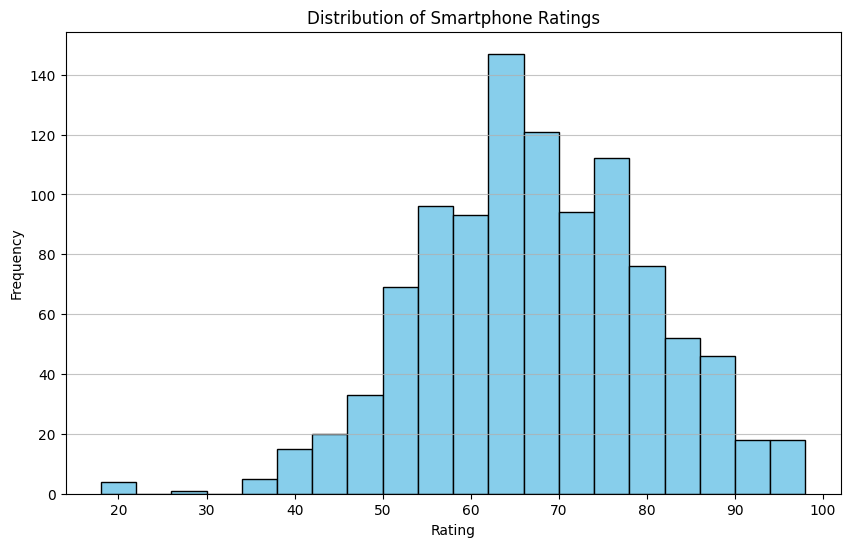

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(df['rating'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Smartphone Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Plot 2: Scatter Plot (Price vs Rating)

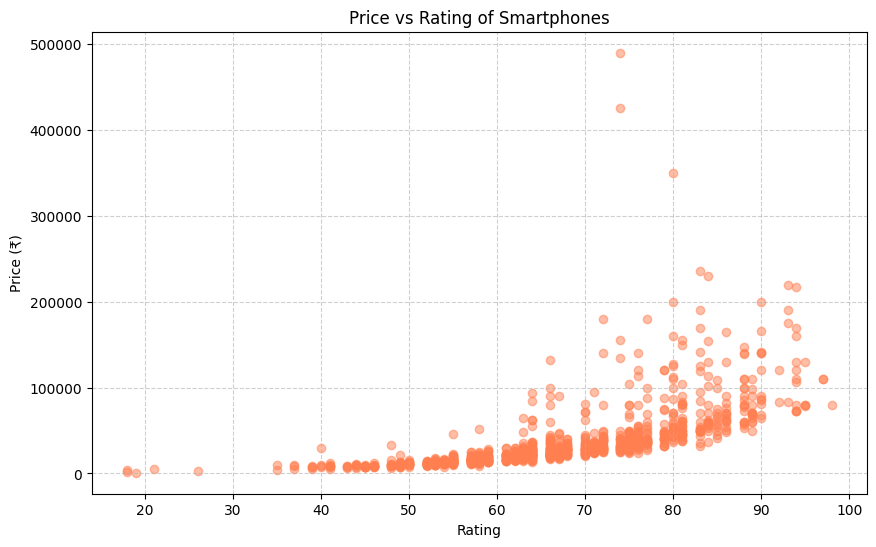

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(df['rating'], df['price'], alpha=0.5, color='coral')
plt.title('Price vs Rating of Smartphones')
plt.xlabel('Rating')
plt.ylabel('Price (₹)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Plot 3: Bar Chart of Top 5 Rated Phones

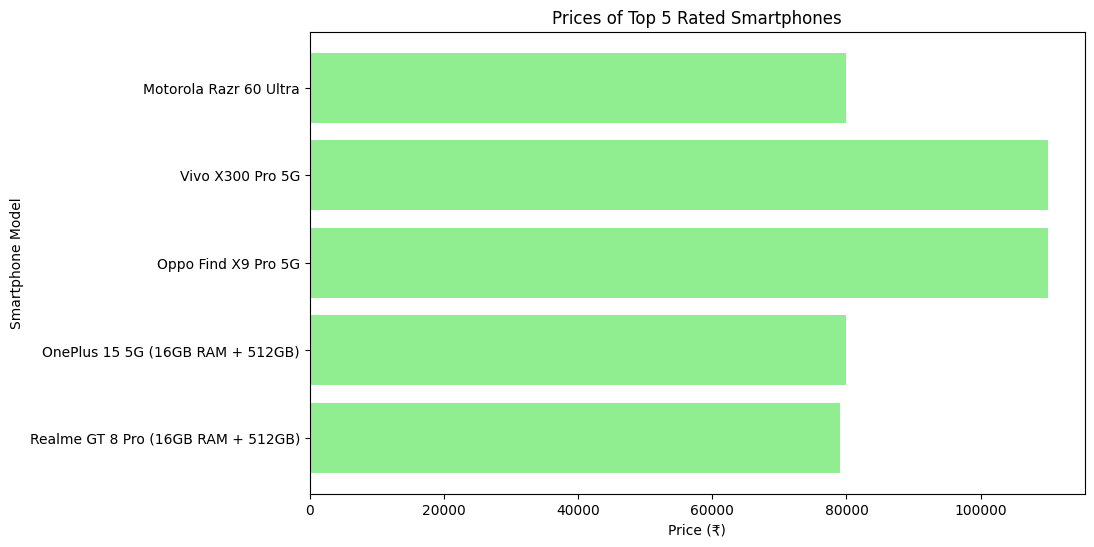

In [24]:
top_5 = df.nlargest(5, 'rating')

plt.figure(figsize=(10, 6))
plt.barh(top_5['model'], top_5['price'], color='lightgreen')
plt.title('Prices of Top 5 Rated Smartphones')
plt.xlabel('Price (₹)')
plt.ylabel('Smartphone Model')
plt.gca().invert_yaxis()
plt.show()

### Plot 4: Pie Chart of Top 5 Smartphone Brands

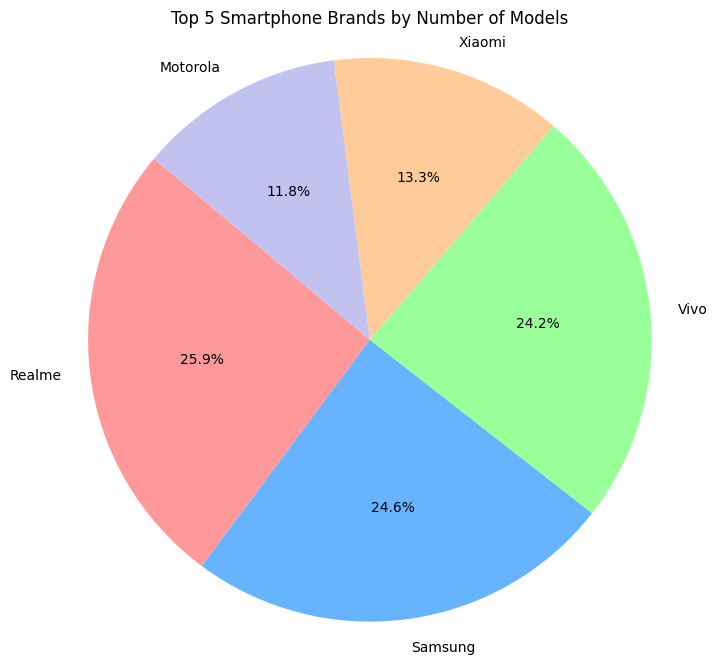

In [25]:
df['brand'] = df['model'].str.split().str[0]

# Get top 5 brands by count
top_brands = df['brand'].value_counts().head(5)

plt.figure(figsize=(8, 8))
plt.pie(top_brands.values, labels=top_brands.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0'])
plt.title('Top 5 Smartphone Brands by Number of Models')
plt.axis('equal') 
plt.show()